Installing Prophet

In [1]:
!pip install prophet


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip show prophet

Name: prophet
Version: 1.3.0
Summary: Automatic Forecasting Procedure
Home-page: 
Author: 
Author-email: "Sean J. Taylor" <sjtz@pm.me>, Ben Letham <bletham@fb.com>
License: MIT
Location: c:\users\pc\appdata\local\programs\python\python310\lib\site-packages
Requires: cmdstanpy, holidays, importlib_resources, matplotlib, numpy, pandas, tqdm
Required-by: 


In [3]:
import sys
print(sys.executable)

C:\Users\pc\AppData\Local\Programs\Python\Python312\python.exe


In [4]:
import sys
!{sys.executable} -m pip install prophet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\pc\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [5]:
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

Importing plotly failed. Interactive plots will not work.


Load & Prepare Data

In [6]:
orders_fc   = pd.read_csv('olist_augmented_data/orders_augmented.csv')
payments_fc = pd.read_csv('olist_augmented_data/order_payments_augmented.csv')


orders_fc['order_purchase_timestamp'] = pd.to_datetime(orders_fc['order_purchase_timestamp'], errors='coerce')

orders_fc = orders_fc[orders_fc['order_status'] == 'delivered']


sales = orders_fc.merge(payments_fc[['order_id', 'payment_value']], on='order_id', how='left')


sales['date'] = sales['order_purchase_timestamp'].dt.date


daily_sales = sales.groupby('date').agg(
    total_revenue = ('payment_value', 'sum'),
    total_orders  = ('order_id',      'nunique')
).reset_index()

daily_sales['date'] = pd.to_datetime(daily_sales['date'])
daily_sales = daily_sales.sort_values('date').reset_index(drop=True)

print(f"Date range   : {daily_sales['date'].min()} → {daily_sales['date'].max()}")
print(f"Total days   : {len(daily_sales)}")
print(f"Total revenue: {daily_sales['total_revenue'].sum():,.2f}")
print(f"\nSample:")
print(daily_sales.head())

Date range   : 2016-09-15 00:00:00 → 2018-10-16 00:00:00
Total days   : 660
Total revenue: 37,823,486.53

Sample:
        date  total_revenue  total_orders
0 2016-09-15           0.00             1
1 2016-10-03         559.53             7
2 2016-10-04        9821.42            54
3 2016-10-05        7209.50            35
4 2016-10-06        6733.52            41


Visualize Raw Sales

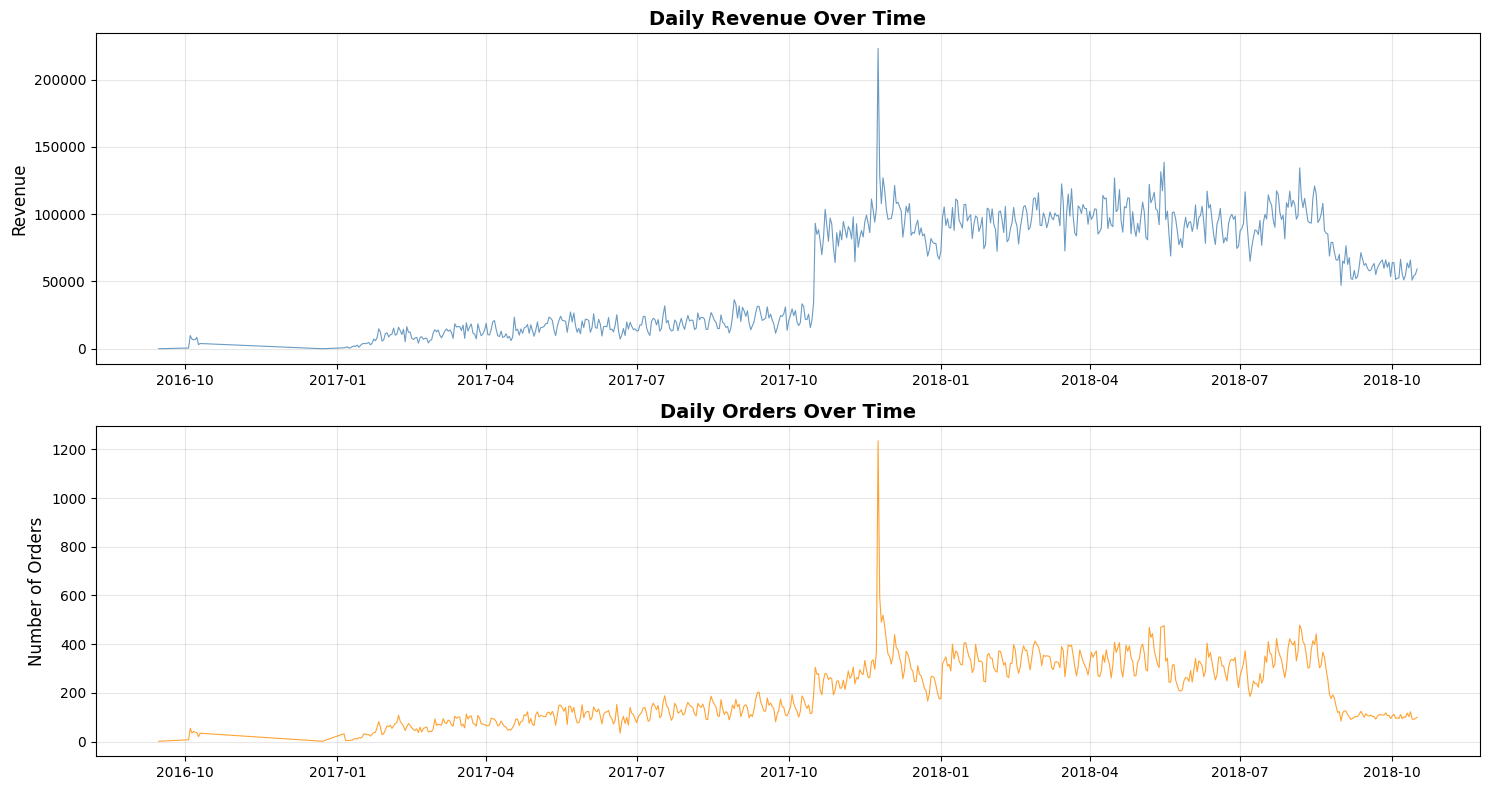

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8))


axes[0].plot(daily_sales['date'], daily_sales['total_revenue'], color='steelblue', linewidth=0.8, alpha=0.8)
axes[0].set_title('Daily Revenue Over Time', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Revenue', fontsize=12)
axes[0].grid(True, alpha=0.3)


axes[1].plot(daily_sales['date'], daily_sales['total_orders'], color='darkorange', linewidth=0.8, alpha=0.8)
axes[1].set_title('Daily Orders Over Time', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Orders', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Train Prophet Model

In [8]:
df_prophet = daily_sales[['date', 'total_revenue']].rename(columns={
    'date'         : 'ds',
    'total_revenue': 'y'
})

split_date  = df_prophet['ds'].max() - pd.Timedelta(days=30)
train_df    = df_prophet[df_prophet['ds'] <= split_date]
test_df     = df_prophet[df_prophet['ds'] >  split_date]

print(f"Train size : {len(train_df)} days")
print(f"Test size  : {len(test_df)} days")

model = Prophet(
    daily_seasonality  = True,
    weekly_seasonality = True,
    yearly_seasonality = True,
    changepoint_prior_scale = 0.05  
)

model.fit(train_df)
print("\nProphet model trained")

Train size : 630 days
Test size  : 30 days


21:20:29 - cmdstanpy - INFO - Chain [1] start processing
21:20:30 - cmdstanpy - INFO - Chain [1] done processing



Prophet model trained


Forecast & Evaluate

In [9]:
future = model.make_future_dataframe(periods=60, freq='D')
forecast = model.predict(future)

test_forecast = forecast[forecast['ds'].isin(test_df['ds'])][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
test_merged   = test_df.merge(test_forecast, on='ds', how='inner')

mae  = mean_absolute_error(test_merged['y'], test_merged['yhat'])
rmse = np.sqrt(mean_squared_error(test_merged['y'], test_merged['yhat']))
mape = (np.abs((test_merged['y'] - test_merged['yhat']) / test_merged['y'].replace(0, np.nan)).mean()) * 100

print("MODEL EVALUATION (on last 30 days):")
print(f"  MAE  : {mae:,.2f}  (avg error in revenue)")
print(f"  RMSE : {rmse:,.2f}")
print(f"  MAPE : {mape:.2f}% (avg % error)")

print(f"\nForecast sample (next 7 days):")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(67).head(7).to_string(index=False))

MODEL EVALUATION (on last 30 days):
  MAE  : 20,632.53  (avg error in revenue)
  RMSE : 24,142.59
  MAPE : 36.21% (avg % error)

Forecast sample (next 7 days):
        ds         yhat   yhat_lower   yhat_upper
2018-09-10 78017.699068 65605.695405 90553.619784
2018-09-11 77310.765876 64087.940081 90546.769090
2018-09-12 77204.691793 64313.955203 89196.197517
2018-09-13 75405.148701 63615.586701 89955.425494
2018-09-14 73470.765628 60878.003268 87043.225844
2018-09-15 67190.238565 54021.837257 80027.694196
2018-09-16 68499.609645 55607.951458 81313.374951


Visualize Forecast

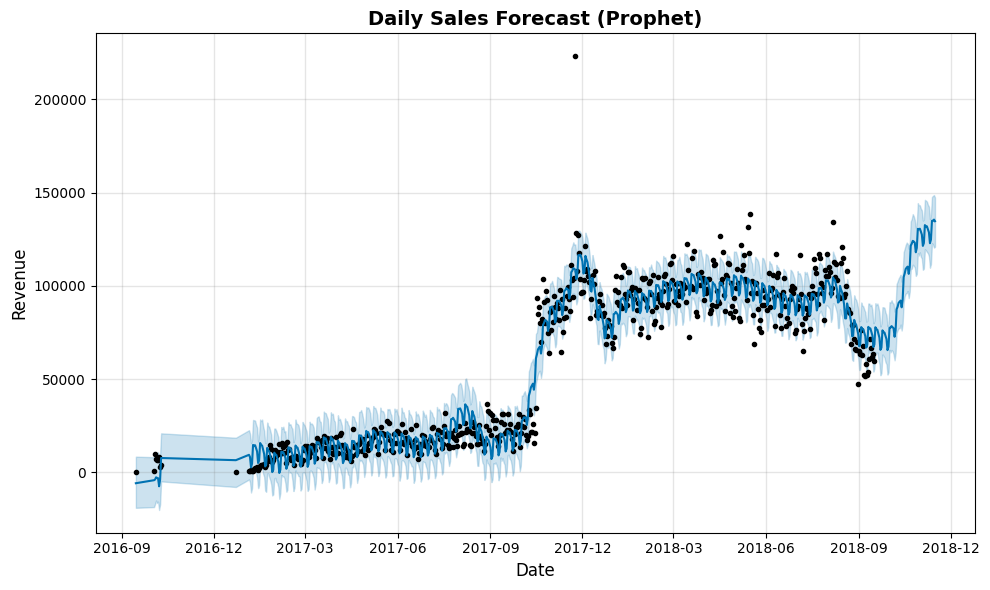

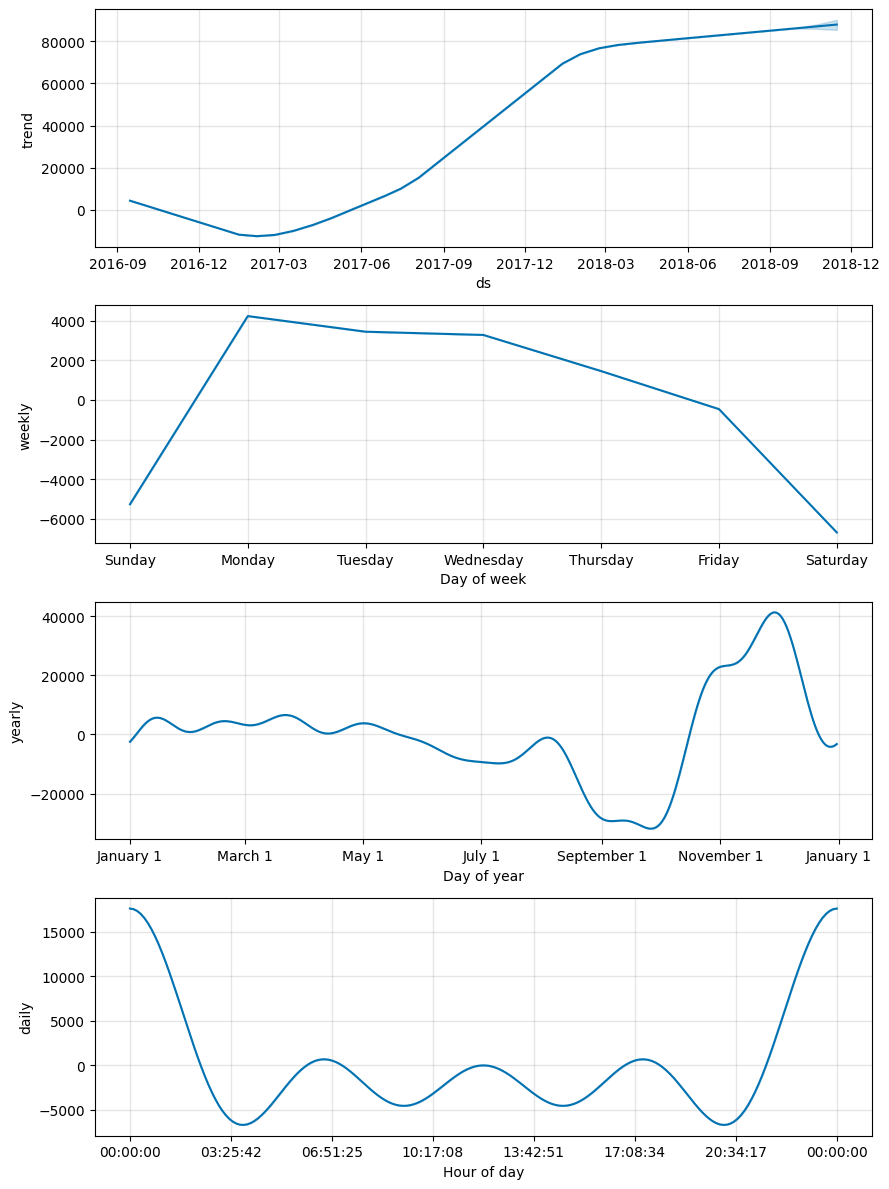

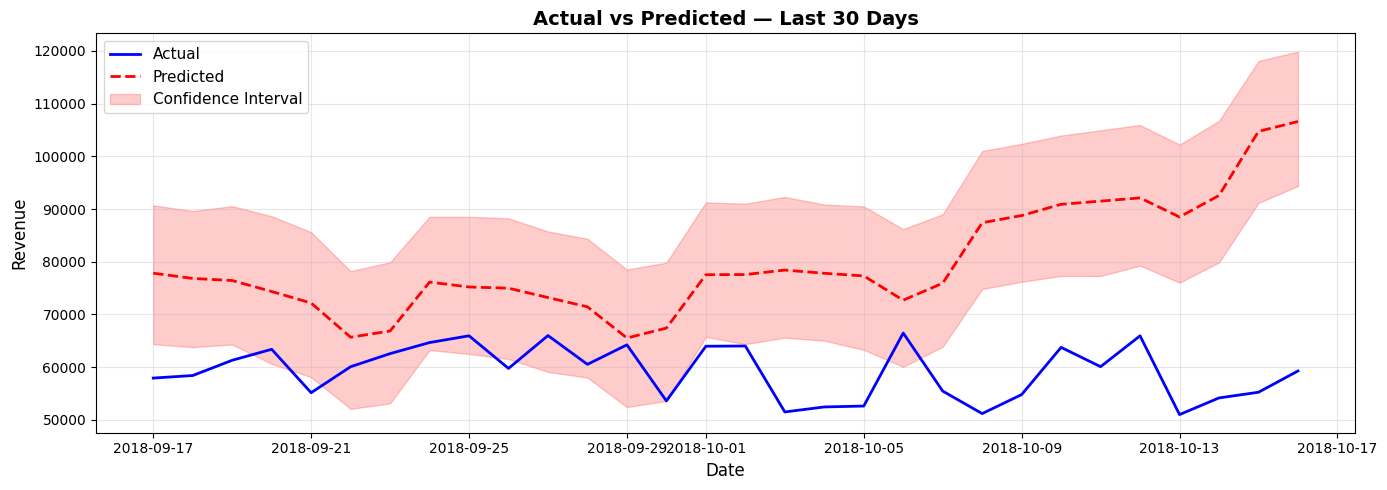

In [10]:

fig1 = model.plot(forecast)
plt.title('Daily Sales Forecast (Prophet)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.tight_layout()
plt.show()


fig2 = model.plot_components(forecast)
plt.tight_layout()
plt.show()


plt.figure(figsize=(14, 5))
plt.plot(test_merged['ds'], test_merged['y'],    'b-', linewidth=2, label='Actual')
plt.plot(test_merged['ds'], test_merged['yhat'], 'r--', linewidth=2, label='Predicted')
plt.fill_between(test_merged['ds'],
                 test_merged['yhat_lower'],
                 test_merged['yhat_upper'],
                 alpha=0.2, color='red', label='Confidence Interval')
plt.title('Actual vs Predicted — Last 30 Days', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Save Results

In [11]:


import os
os.makedirs('olist_augmented_data', exist_ok=True)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv(
    'olist_augmented_data/sales_forecast.csv', index=False
)


daily_sales.to_csv('olist_augmented_data/daily_sales.csv', index=False)

print(" Saved: olist_augmented_data/sales_forecast.csv")
print(" Saved: olist_augmented_data/daily_sales.csv")

print(f"""

Model            : Prophet
Granularity      : Daily
Train Period     : {train_df['ds'].min().date()} → {train_df['ds'].max().date()}
Test Period      : {test_df['ds'].min().date()} → {test_df['ds'].max().date()}
Forecast Horizon : 60 days ahead

MODEL PERFORMANCE:
MAE              : {mae:,.2f}
RMSE             : {rmse:,.2f}
MAPE             : {mape:.2f}%

""")

 Saved: olist_augmented_data/sales_forecast.csv
 Saved: olist_augmented_data/daily_sales.csv


Model            : Prophet
Granularity      : Daily
Train Period     : 2016-09-15 → 2018-09-16
Test Period      : 2018-09-17 → 2018-10-16
Forecast Horizon : 60 days ahead

MODEL PERFORMANCE:
MAE              : 20,632.53
RMSE             : 24,142.59
MAPE             : 36.21%


